# Tutorial 05 — Créer un nouveau modèle non linéaire pairwise : Lotka-Volterra

Ce tutorial montre pas à pas comment ajouter un **nouveau modèle non linéaire pairwise** dans `awesomepkf`,
en prenant l'exemple du modèle proie-prédateur de **Lotka-Volterra** discrétisé à l'ordre 1.

**Ce que vous allez apprendre :**

1. Comprendre la structure d'un modèle pairwise scalaire (`BaseModelGxGy`, dim_x=1, dim_y=1)
2. Générer les fichiers Python du modèle pairwise et de sa version augmentée
3. Vérifier que les modèles sont automatiquement découverts par `ModelFactoryNonLinear`
4. Explorer le modèle (paramètres, équations LaTeX, jacobiens symboliques auto-générés)
5. Simuler une trajectoire et visualiser le portrait de phase
6. Appliquer les filtres EPKF, UPKF, PPF et PF

**Prérequis :** Tutorial 02 — Nonlinear Models

## Setup

In [8]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from prg import (
    NonLinear_EPKF,
    NonLinear_UPKF,
    NonLinear_PPF,
    NonLinear_PF,
    ParamNonLinear,
    ModelFactoryNonLinear,
    __version__,
)

print(f"awesomepkf version: {__version__}")

SEED = 42
N    = 200

awesomepkf version: 0.1.0


---
## 1. Le modèle de Lotka-Volterra pairwise

### Dynamique continue

Le modèle de Lotka-Volterra décrit l'évolution de deux populations couplées :

$$\dot{x} = \alpha\, x - \beta\, x\, y, \qquad \dot{y} = \delta\, x\, y - \gamma\, y$$

| Variable | Rôle |
|----------|------|
| $x$ | Population de proies (scalaire) |
| $y$ | Population de prédateurs (scalaire) |

| Paramètre | Rôle | Valeur |
|-----------|------|--------|
| $\alpha$ | Taux de croissance des proies | 0.5 |
| $\beta$ | Taux de prédation | 0.1 |
| $\gamma$ | Taux de mortalité des prédateurs | 0.4 |
| $\delta$ | Efficacité de conversion | 0.05 |

**Point d'équilibre non trivial :** $(x^*, y^*) = (\gamma/\delta,\; \alpha/\beta) = (8,\; 5)$

---
### Discrétisation Euler explicite (ordre 1), pas $\Delta t$

$$x^{k+1} = (1 + \alpha\Delta t)\,x^k - \beta\Delta t\cdot x^k y^k$$
$$y^{k+1} = (1 - \gamma\Delta t)\,y^k + \delta\Delta t\cdot x^k y^k$$

---
### Formulation pairwise (`BaseModelGxGy`, dim_x=1, dim_y=1)

Dans un modèle pairwise, il y a **deux variables scalaires** ($x$ et $y$)
et **deux équations scalaires** ($g_x$ et $g_y$) qui peuvent chacune dépendre de $x$ **et** $y$ :

$$g_x(x,\, y,\, v^x) = (1 + \alpha\Delta t)\,x - \beta\Delta t\cdot x\,y + v^x$$
$$g_y(x,\, y,\, v^y) = (1 - \gamma\Delta t)\,y + \delta\Delta t\cdot x\,y + v^y$$

Le modèle LV est **naturellement pairwise** : la dynamique des proies dépend des prédateurs ($y$)
et vice-versa.

> **Note :** les jacobiens $A_n = \partial g / \partial z$ et $B_n = \partial g / \partial v$
> sont **calculés automatiquement par SymPy** dans `BaseModelGxGy`.
> Il suffit de définir `symbolic_model()`.

---
## 2. Générer le fichier du modèle pairwise

La cellule suivante génère et écrit directement le fichier dans `prg/models/nonLinear/`.
La factory `ModelFactoryNonLinear` scanne ce répertoire automatiquement — **aucune
modification du code existant n'est nécessaire**.

> Le chemin relatif `../prg/models/nonLinear/` est valide si le notebook est exécuté
> depuis le répertoire `ipynb/`.

In [9]:
pairwise_code = '''\
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import sympy as sp

from prg.models.nonLinear.base_model_gxgy import BaseModelGxGy
from prg.utils.exceptions import NumericalError

__all__ = ["Model_x1_y1_LotkaVolterra_pairwise"]


class Model_x1_y1_LotkaVolterra_pairwise(BaseModelGxGy):
    """
    Modele proie-predateur de Lotka-Volterra discretise a l ordre 1
    (Euler explicite), forme pairwise scalaire (dim_x=1, dim_y=1).

    x = population de proies    (scalaire)
    y = population de predateurs (scalaire)

    Parametres :
        ALPHA = 0.5   taux de croissance des proies
        BETA  = 0.1   taux de predation
        GAMMA = 0.4   taux de mortalite des predateurs
        DELTA = 0.05  efficacite de conversion predation -> croissance
        DT    = 0.3   pas de discretisation temporelle

    Equation de transition gx(x, y, vx) :
        gx = (1 + ALPHA*DT)*x - BETA*DT*x*y + vx

    Equation d observation gy(x, y, vy) :
        gy = (1 - GAMMA*DT)*y + DELTA*DT*x*y + vy

    Point d equilibre non trivial : (x*, y*) = (GAMMA/DELTA, ALPHA/BETA) = (8, 5)

    Les jacobiens An = dg/dz et Bn = dg/dn sont calcules automatiquement
    par SymPy dans BaseModelGxGy.
    """

    ALPHA: float = 0.5
    BETA:  float = 0.1
    GAMMA: float = 0.4
    DELTA: float = 0.05
    DT:    float = 0.3

    def __init__(self):
        # Les attributs de classe sont accessibles avant super().__init__()
        # car super() appelle _build_symbolic_model() -> symbolic_model()
        super().__init__(dim_x=1, dim_y=1, model_type="nonlinear")

        # Point d equilibre non trivial
        x_eq = self.GAMMA / self.DELTA   # 8.0
        y_eq = self.ALPHA / self.BETA    # 5.0

        try:
            self.mQ, self.mz0, self.Pz0 = self._init_random_params(
                self.dim_x, self.dim_y, 0.10, seed=None
            )
            # Initialisation autour du point d equilibre
            self.mz0 = np.array([[x_eq], [y_eq]])
        except (ValueError, np.exceptions.AxisError) as e:
            raise NumericalError(
                f"[{self.MODEL_NAME}] Initialization failed: {e}"
            ) from e

    # ------------------------------------------------------------------
    def symbolic_model(self, sx, sy, st, su):
        x, y, t, u = sx[0], sy[0], st[0], su[0]

        sgx = sp.Matrix([
            (1 + self.ALPHA * self.DT) * x - self.BETA * self.DT * x * y + t
        ])
        sgy = sp.Matrix([
            (1 - self.GAMMA * self.DT) * y + self.DELTA * self.DT * x * y + u
        ])

        return sgx, sgy
'''

target_pairwise = Path("../prg/models/nonLinear/model_x1_y1_LotkaVolterra_pairwise.py")
target_pairwise.write_text(pairwise_code, encoding="utf-8")
print(f"Fichier cree : {target_pairwise.resolve()}")

Fichier cree : /Users/MacBook_Derrode/Documents/ProjetsRecherche/Clement/awesomepkf/prg/models/nonLinear/model_x1_y1_LotkaVolterra_pairwise.py


---
## 3. Générer le fichier du modèle augmenté

La version **augmentée** réinterprète l'état joint $z = (x, y)$ du modèle pairwise
comme un **état augmenté** $x_{aug} = (x_A, x_B)$ de dimension 2,
avec une observation scalaire $h(x_{aug}) = x_B$ (les prédateurs).

| | Pairwise | Augmenté |
|-|----------|----------|
| dim_x | 1 | 2 |
| dim_y | 1 | 1 |
| État | $x$ (proies) | $x_{aug} = (x_A, x_B)$ = (proies, préd.) |
| Observation | $y$ (préd.) | $h(x_{aug}) = x_B$ (préd.) |

La dynamique $f(x_{aug})$ reprend exactement $g_x$ et $g_y$ du modèle pairwise.

In [10]:
augmented_code = '''\
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import sympy as sp

from prg.models.nonLinear.base_model_fxhx import BaseModelFxHx
from prg.models.nonLinear.model_x1_y1_LotkaVolterra_pairwise import (
    Model_x1_y1_LotkaVolterra_pairwise,
)
from prg.utils.exceptions import NumericalError

__all__ = ["Model_x1_y1_LotkaVolterra_augmented"]


class Model_x1_y1_LotkaVolterra_augmented(BaseModelFxHx):
    """
    Version augmentee de Model_x1_y1_LotkaVolterra_pairwise (BaseModelFxHx).

    Etat augmente : x_aug = [xA, xB]
        xA = population de proies    (etat original x)
        xB = population de predateurs (observation precedente y)
    dim_x = 2, dim_y = 1, augmented = True.

    Dynamique  : f(x_aug) = [gx(xA, xB), gy(xA, xB)]
    Observation: h(x_aug) = xB  (predateurs)
    """

    def __init__(self):
        self.mod = Model_x1_y1_LotkaVolterra_pairwise()
        dim_x  = self.mod.dim_x   # 1
        dim_y  = self.mod.dim_y   # 1
        dim_xy = self.mod.dim_xy  # 2

        super().__init__(
            dim_x=dim_x + dim_y,   # 2
            dim_y=dim_y,           # 1
            model_type="nonlinear",
            augmented=True,
        )

        try:
            self.mQ = np.zeros((dim_xy + dim_y, dim_xy + dim_y))
            self.mQ[0:dim_xy, 0:dim_xy] = self.mod.mQ

            self.mz0 = np.zeros((dim_xy + dim_y, 1))
            self.mz0[0:dim_xy] = self.mod.mz0
            self.mz0[dim_xy : dim_xy + dim_y] = self.mz0[dim_xy - dim_y : dim_xy]

            self.Pz0 = np.zeros((dim_xy + dim_y, dim_xy + dim_y))
            self.Pz0[0:dim_xy, 0:dim_xy] = self.mod.Pz0
            self.Pz0[dim_xy : dim_xy + dim_y, :] = self.Pz0[dim_xy - dim_y : dim_xy, :]
            self.Pz0[:, dim_xy : dim_xy + dim_y] = self.Pz0[:, dim_xy - dim_y : dim_xy]

        except (ValueError, IndexError) as e:
            raise NumericalError(
                f"[{self.MODEL_NAME}] Initialization failed: {e}"
            ) from e

    # ------------------------------------------------------------------
    def symbolic_model(self, sx, st, su):
        """
        sx : sp.Matrix(2, 1) -> [xA, xB]  (proies, predateurs)
        st : sp.Matrix(2, 1) -> [t0, t1]  (bruits process)
        su : sp.Matrix(1, 1) -> [u0]      (bruit observation, non utilise dans h)
        """
        mx0 = sp.Symbol("x0", real=True)
        my0 = sp.Symbol("y0", real=True)
        mt0 = sp.Symbol("t0", real=True)
        mu0 = sp.Symbol("u0", real=True)

        subs_state = {mx0: sx[0], my0: sx[1]}

        sfx = sp.Matrix([
            self.mod._sgx.subs({**subs_state, mt0: st[0]})[0],  # gx(xA, xB)
            self.mod._sgy.subs({**subs_state, mu0: st[1]})[0],  # gy(xA, xB)
        ])

        # h(x_aug) = xB = predateurs
        shx = sp.Matrix([[sx[1]]])

        # -- Diagnostic -----------------------------------------------
        expected_fx = set(sx.free_symbols) | set(st.free_symbols)
        expected_hx = set(sx.free_symbols) | set(su.free_symbols)
        residual_fx = sfx.free_symbols - expected_fx
        residual_hx = shx.free_symbols - expected_hx

        if residual_fx:
            print(f"[WARN] sfx contient des symboles non attendus : {residual_fx}")
        if residual_hx:
            print(f"[WARN] shx contient des symboles non attendus : {residual_hx}")

        return sfx, shx
'''

target_augmented = Path("../prg/models/nonLinear/model_x1_y1_LotkaVolterra_augmented.py")
target_augmented.write_text(augmented_code, encoding="utf-8")
print(f"Fichier cree : {target_augmented.resolve()}")

Fichier cree : /Users/MacBook_Derrode/Documents/ProjetsRecherche/Clement/awesomepkf/prg/models/nonLinear/model_x1_y1_LotkaVolterra_augmented.py


---
## 4. Vérifier l'enregistrement dans la factory

`ModelFactoryNonLinear` scanne automatiquement `prg/models/nonLinear/` et enregistre
toute classe concrète héritant de `BaseModelNonLinear`.
Le nom de modèle est dérivé du nom de classe (premier caractère mis en minuscule) :

- `Model_x1_y1_LotkaVolterra_pairwise` → `model_x1_y1_LotkaVolterra_pairwise`
- `Model_x1_y1_LotkaVolterra_augmented` → `model_x1_y1_LotkaVolterra_augmented`

> Si le noyau Python était démarré avant la création des fichiers,
> relancez-le (`Kernel > Restart`) et réexécutez depuis la cellule Setup.

In [11]:
# Forcer la redécouverte si la factory a déjà scanné avant l'ajout des fichiers
ModelFactoryNonLinear._registry.clear()

models = sorted(ModelFactoryNonLinear.list_models())
print(f"{len(models)} modeles non lineaires disponibles:")
for m in models:
    marker = "  <<< NOUVEAU" if "LotkaVolterra" in m else ""
    print(f"  {m}{marker}")

14 modeles non lineaires disponibles:
  model_x1_y1_Cubique_classic
  model_x1_y1_ExpSaturant_classic
  model_x1_y1_Gordon_classic
  model_x1_y1_LotkaVolterra_augmented  <<< NOUVEAU
  model_x1_y1_LotkaVolterra_pairwise  <<< NOUVEAU
  model_x1_y1_Sinus_classic
  model_x1_y1_augmented
  model_x1_y1_pairwise
  model_x2_y1_Rapport_classic
  model_x2_y1_augmented
  model_x2_y1_classic
  model_x2_y1_pairwise
  model_x2_y2_augmented
  model_x2_y2_pairwise


---
## 5. Explorer le modèle

### 5.1 Paramètres et informations de base

In [12]:
model_lv = ModelFactoryNonLinear.create("model_x1_y1_LotkaVolterra_pairwise")
params   = model_lv.get_params()

print(f"Modele   : {model_lv}")
print(f"dim_x    : {params['dim_x']}  (x = proies, scalaire)")
print(f"dim_y    : {params['dim_y']}  (y = predateurs, scalaire)")
print(f"Pairwise : {params['pairwiseModel']}")
print()
print(f"Point d equilibre : x* = {model_lv.GAMMA/model_lv.DELTA:.1f} (proies),  "
      f"y* = {model_lv.ALPHA/model_lv.BETA:.1f} (predateurs)")
print()
print("mz0 (etat initial moyen) [x, y] :", params['mz0'].flatten())
print()
print("mQ (covariance du bruit joint, shape", params['mQ'].shape, "):")
print(np.round(params['mQ'], 4))

Modele   : Model_x1_y1_LotkaVolterra_pairwise(dim_x=1, dim_y=1)
dim_x    : 1  (x = proies, scalaire)
dim_y    : 1  (y = predateurs, scalaire)
Pairwise : True

Point d equilibre : x* = 8.0 (proies),  y* = 5.0 (predateurs)

mz0 (etat initial moyen) [x, y] : [8. 5.]

mQ (covariance du bruit joint, shape (2, 2) ):
[[0.0077 0.0031]
 [0.0031 0.0043]]


### 5.2 Équations et jacobiens — générés automatiquement par SymPy

In [13]:
from IPython.display import display, Math

display(Math(model_lv.latex_model()))

<IPython.core.display.Math object>

In [14]:
import sympy as sp

print("=== gx (transition des proies) ===")
sp.pprint(model_lv._sgx, use_unicode=True)
print()
print("=== gy (dynamique des predateurs) ===")
sp.pprint(model_lv._sgy, use_unicode=True)
print()
print("=== An = dg/dz (jacobien calcule par SymPy) ===")
sp.pprint(model_lv._sAn, use_unicode=True)
print()
print("=== Bn = dg/dnoise ===")
sp.pprint(model_lv._sBn, use_unicode=True)

=== gx (transition des proies) ===
[t₀ - 0.03⋅x₀⋅y₀ + 1.15⋅x₀]

=== gy (dynamique des predateurs) ===
[u₀ + 0.015⋅x₀⋅y₀ + 0.88⋅y₀]

=== An = dg/dz (jacobien calcule par SymPy) ===
⎡1.15 - 0.03⋅y₀     -0.03⋅x₀    ⎤
⎢                               ⎥
⎣   0.015⋅y₀     0.015⋅x₀ + 0.88⎦

=== Bn = dg/dnoise ===
⎡1  0⎤
⎢    ⎥
⎣0  1⎦


---
## 6. Portrait de phase — comportement déterministe

On simule le système **sans bruit** pour visualiser les orbites fermées
caractéristiques du modèle de Lotka-Volterra autour du point d'équilibre $(8, 5)$.

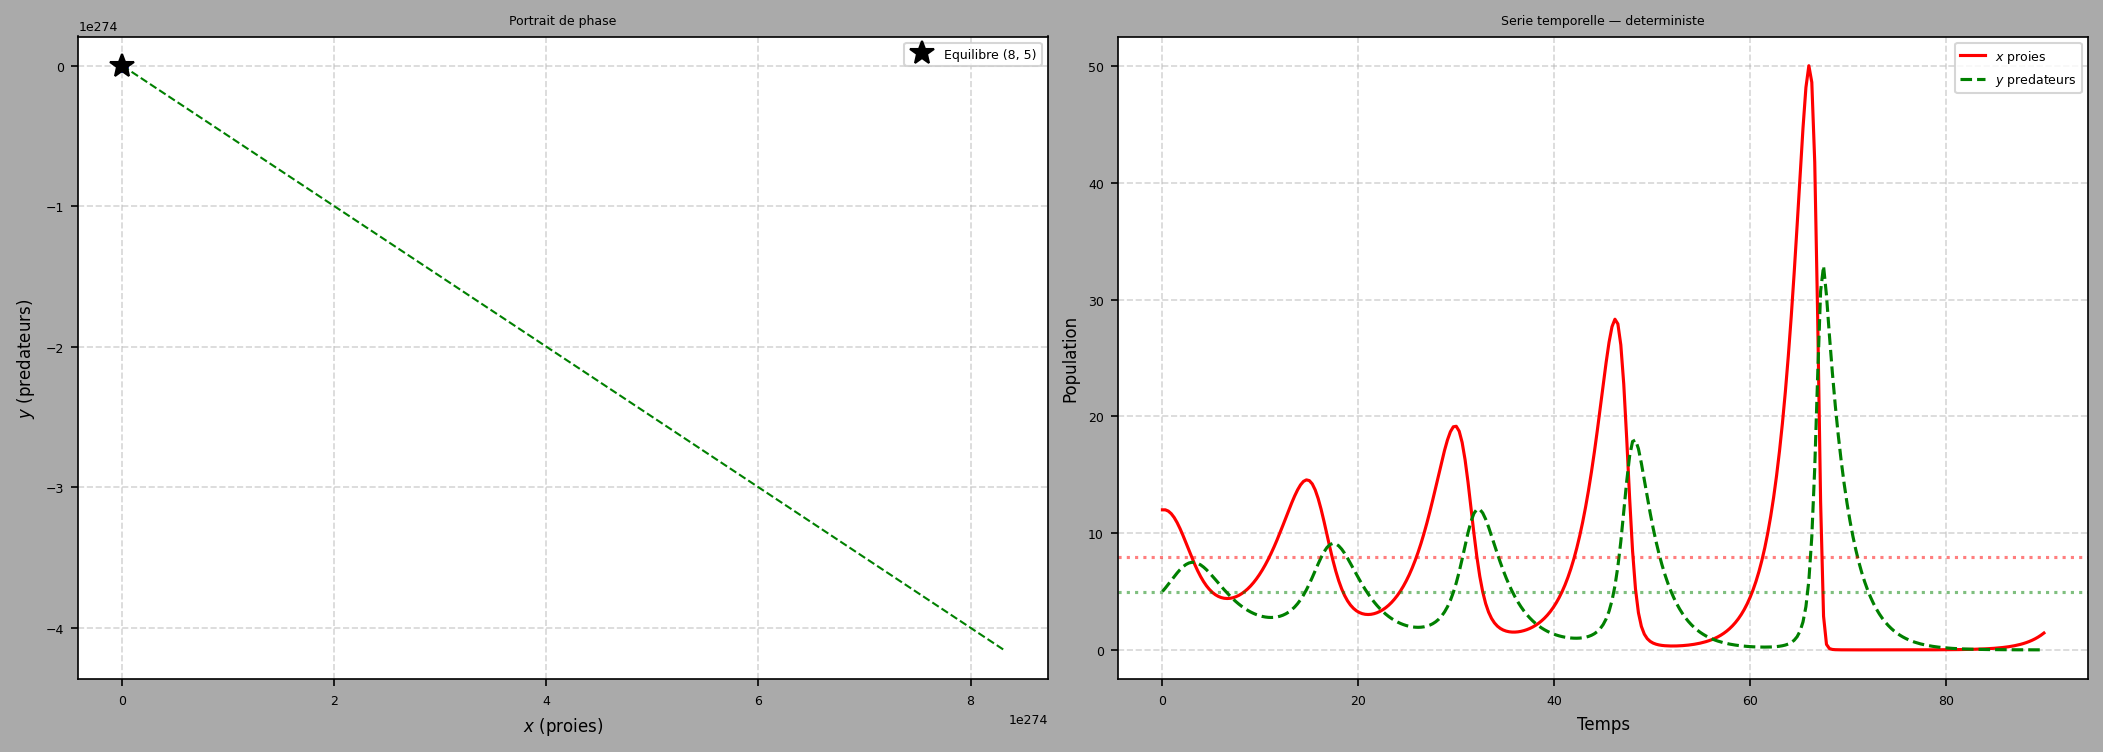

In [15]:
def simulate_lv_det(x0, y0, alpha, beta, gamma, delta, dt, n_steps):
    """Simule le systeme LV discret sans bruit."""
    x, y = x0, y0
    traj = [(x, y)]
    for _ in range(n_steps):
        x, y = (1 + alpha*dt)*x - beta*dt*x*y, (1 - gamma*dt)*y + delta*dt*x*y
        traj.append((x, y))
    return np.array(traj)

alpha = model_lv.ALPHA
beta  = model_lv.BETA
gamma = model_lv.GAMMA
delta = model_lv.DELTA
dt    = model_lv.DT
x_eq, y_eq = gamma / delta, alpha / beta   # (8.0, 5.0)

# Orbites de rayon croissant autour de l equilibre
init_conds = [(x_eq+2, y_eq), (x_eq+4, y_eq), (x_eq+6, y_eq)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for (x0, y0), c in zip(init_conds, ["C0", "C1", "C2"]):
    traj = simulate_lv_det(x0, y0, alpha, beta, gamma, delta, dt, 600)
    ax.plot(traj[:, 0], traj[:, 1], color=c, lw=1.0)
    ax.plot(x0, y0, "o", color=c, ms=5)
ax.plot(x_eq, y_eq, "k*", ms=12, label=f"Equilibre ({x_eq:.0f}, {y_eq:.0f})")
ax.set_xlabel(r"$x$ (proies)"); ax.set_ylabel(r"$y$ (predateurs)")
ax.set_title("Portrait de phase"); ax.legend(); ax.grid(True, ls="--", alpha=0.5)

ax = axes[1]
traj = simulate_lv_det(x_eq+4, y_eq, alpha, beta, gamma, delta, dt, 300)
t_ax = np.arange(len(traj)) * dt
ax.plot(t_ax, traj[:, 0], color="C0", lw=1.5, label=r"$x$ proies")
ax.plot(t_ax, traj[:, 1], color="C1", lw=1.5, label=r"$y$ predateurs")
ax.axhline(x_eq, color="C0", ls=":", alpha=0.5); ax.axhline(y_eq, color="C1", ls=":", alpha=0.5)
ax.set_xlabel("Temps"); ax.set_ylabel("Population")
ax.set_title("Serie temporelle — deterministe"); ax.legend(); ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout(); plt.show()

---
## 7. Trajectoire stochastique

On simule maintenant le modèle **avec bruit** et on visualise l'état joint $(x, y)$
ainsi que le portrait de phase stochastique.

IndexError: index 1 is out of bounds for axis 1 with size 1

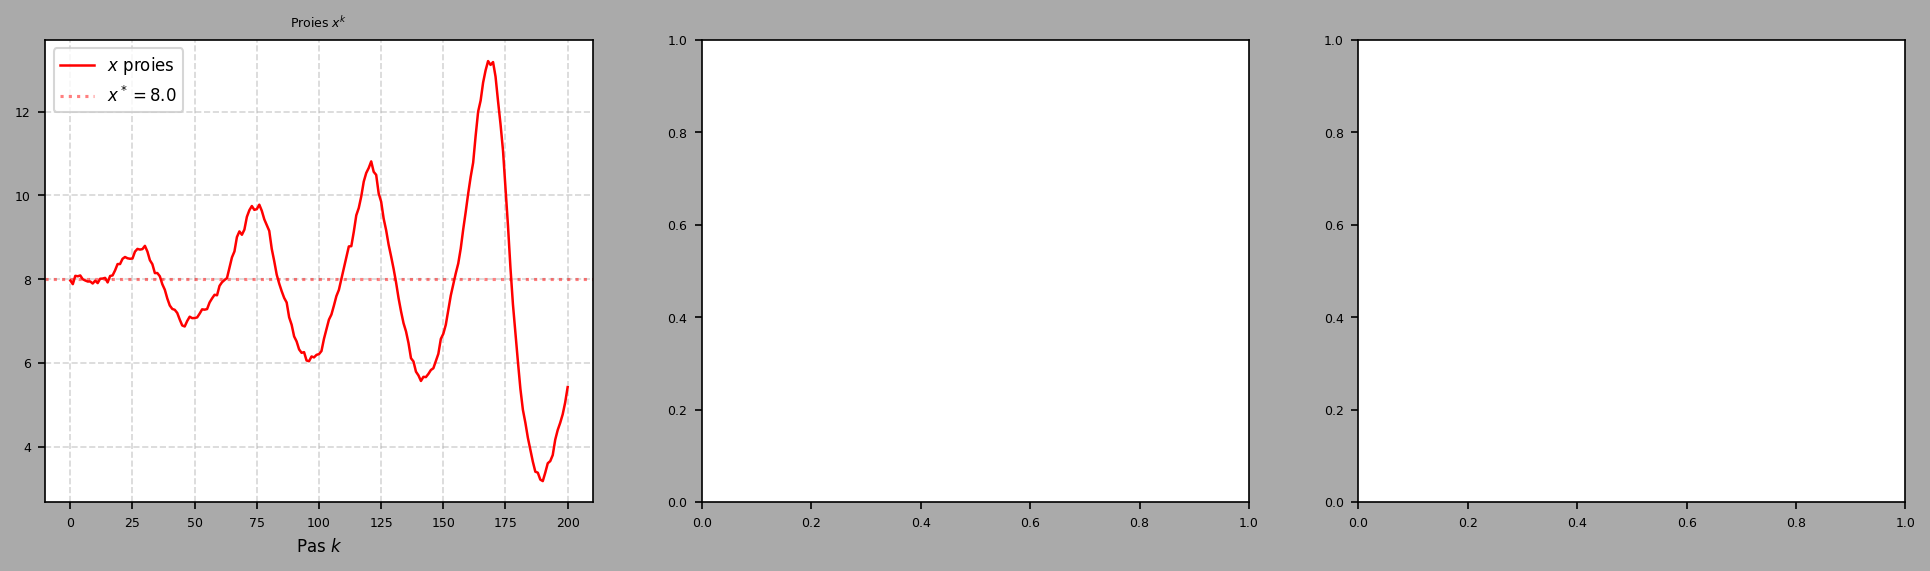

In [16]:
def make_param(model):
    p = model.get_params().copy()
    dx = p.pop("dim_x")
    dy = p.pop("dim_y")
    return ParamNonLinear(0, dx, dy, **p)

def extract(results):
    """Extrait (z_true, z_update) depuis les resultats d un filtre."""
    xu = np.array([r[4].flatten() for r in results if r[4] is not None])
    M  = len(xu)
    xt = np.array([r[1].flatten() for r in results[:M]])
    return xt, xu

def mse(xt, xu):
    return float(np.mean((xt - xu) ** 2))

param_lv  = make_param(model_lv)
epkf_sim  = NonLinear_EPKF(param_lv, sKey=SEED)
sim_data  = epkf_sim.simulate_N_data(N)

# z_true = (x_prey, y_pred), shape (N+1, 2)
z_true = np.array([r[1].flatten() for r in sim_data])
t_sim  = np.arange(len(z_true))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(t_sim, z_true[:, 0], color="C0", lw=1.2, label=r"$x$ proies")
axes[0].axhline(x_eq, color="C0", ls=":", alpha=0.5, label=f"$x^*={x_eq}$")
axes[0].set_xlabel("Pas $k$"); axes[0].set_title(r"Proies $x^k$")
axes[0].legend(fontsize=8); axes[0].grid(True, ls="--", alpha=0.5)

axes[1].plot(t_sim, z_true[:, 1], color="C1", lw=1.2, label=r"$y$ predateurs")
axes[1].axhline(y_eq, color="C1", ls=":", alpha=0.5, label=f"$y^*={y_eq}$")
axes[1].set_xlabel("Pas $k$"); axes[1].set_title(r"Predateurs $y^k$")
axes[1].legend(fontsize=8); axes[1].grid(True, ls="--", alpha=0.5)

axes[2].plot(z_true[:, 0], z_true[:, 1], color="C3", lw=0.8, alpha=0.8)
axes[2].plot(z_true[0, 0], z_true[0, 1], "ko", ms=6, label="Depart")
axes[2].plot(x_eq, y_eq, "k*", ms=12, label=f"Eq. ({x_eq:.0f},{y_eq:.0f})")
axes[2].set_xlabel(r"$x$ proies"); axes[2].set_ylabel(r"$y$ predateurs")
axes[2].set_title("Portrait de phase stochastique")
axes[2].legend(fontsize=8); axes[2].grid(True, ls="--", alpha=0.5)

plt.tight_layout(); plt.show()

---
## 8. Filtrage — EPKF, UPKF, PPF, PF

On applique les quatre filtres sur la **même trajectoire**.
Pour chaque filtre, l'état estimé $\hat{z} = (\hat{x}, \hat{y})$ est comparé
à l'état vrai $z = (x, y)$.

In [ ]:
epkf = NonLinear_EPKF(param_lv, sKey=SEED)
res_epkf = epkf.process_N_data(N=None, data_generator=iter(sim_data))
xt_epkf, xu_epkf = extract(res_epkf)
print(f"EPKF                   MSE = {mse(xt_epkf, xu_epkf):.6f}")

upkf = NonLinear_UPKF(param_lv, sigmaSet="wan2000", sKey=SEED)
res_upkf = upkf.process_N_data(N=None, data_generator=iter(sim_data))
xt_upkf, xu_upkf = extract(res_upkf)
print(f"UPKF (wan2000)         MSE = {mse(xt_upkf, xu_upkf):.6f}")

ppf = NonLinear_PPF(param_lv, n_particles=500, sKey=SEED)
res_ppf = ppf.process_N_data(N=None, data_generator=iter(sim_data))
xt_ppf, xu_ppf = extract(res_ppf)
print(f"PPF  (500 particules)  MSE = {mse(xt_ppf, xu_ppf):.6f}")

pf = NonLinear_PF(param_lv, n_particles=500, sKey=SEED)
res_pf = pf.process_N_data(N=None, data_generator=iter(sim_data))
xt_pf, xu_pf = extract(res_pf)
print(f"PF   (500 particules)  MSE = {mse(xt_pf, xu_pf):.6f}")

### 8.1 Estimées vs état vrai

In [ ]:
M   = min(len(xu_epkf), len(xu_upkf), len(xu_ppf), len(xu_pf))
t   = np.arange(M)
WIN = slice(0, min(M, 100))

filters = {
    "EPKF":        (xu_epkf[:M], "C0", "-"),
    "UPKF (wan)": (xu_upkf[:M], "C1", "--"),
    "PPF":         (xu_ppf[:M],  "C2", "-."),
    "PF":          (xu_pf[:M],   "C3", ":"),
}

comp_labels = [r"$x$ (proies)", r"$y$ (predateurs)"]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for i, (ax, lbl) in enumerate(zip(axes, comp_labels)):
    ax.plot(t[WIN], xt_epkf[WIN, i], color="black", lw=1.2, label="Vrai")
    for name, (xu_, c, ls) in filters.items():
        ax.plot(t[WIN], xu_[WIN, i], color=c, lw=1.1, ls=ls, label=name)
    ax.set_ylabel(lbl); ax.legend(fontsize=8, ncol=5); ax.grid(True, ls="--", alpha=0.5)
axes[-1].set_xlabel("Pas de temps $k$ (100 premiers)")
fig.suptitle("Comparaison des filtres — Lotka-Volterra pairwise", y=1.01)
plt.tight_layout(); plt.show()

### 8.2 MSE par filtre et par composante

In [ ]:
filter_list = [
    ("EPKF",       xt_epkf[:M], xu_epkf[:M], "C0"),
    ("UPKF (wan)", xt_upkf[:M], xu_upkf[:M], "C1"),
    ("PPF",        xt_ppf[:M],  xu_ppf[:M],  "C2"),
    ("PF",         xt_pf[:M],   xu_pf[:M],   "C3"),
]
comp_labels_short = [r"$x$ proies", r"$y$ predateurs"]
x_pos = np.arange(2)
w     = 0.18

fig, ax = plt.subplots(figsize=(8, 4))
for k, (name, xt_, xu_, c) in enumerate(filter_list):
    vals = [float(np.mean((xt_[:, i] - xu_[:, i])**2)) for i in range(2)]
    ax.bar(x_pos + (k - 1.5)*w, vals, w, label=name, color=c)
ax.set_xticks(x_pos); ax.set_xticklabels(comp_labels_short)
ax.set_ylabel("MSE"); ax.set_title("MSE par composante et par filtre")
ax.legend(); ax.grid(True, axis="y", ls="--", alpha=0.5)
plt.tight_layout(); plt.show()

---
## 9. Modèle augmenté (dim_x=2, dim_y=1)

Le modèle augmenté a pour état $x_{aug} = (x_A, x_B)$ = (proies, prédateurs)
et pour observation scalaire $h(x_{aug}) = x_B$ (les prédateurs).
Il est compatible avec EPKF, UPKF et PF (mais pas PPF, car non pairwise).

In [ ]:
model_aug  = ModelFactoryNonLinear.create("model_x1_y1_LotkaVolterra_augmented")
params_aug = model_aug.get_params()

print(f"Modele augmente : {model_aug}")
print(f"dim_x : {params_aug['dim_x']}  -> x_aug = (xA=proies, xB=predateurs)")
print(f"dim_y : {params_aug['dim_y']}  -> h(x_aug) = xB (predateurs)")
print(f"augmented     : {model_aug.augmented}")
print(f"pairwiseModel : {params_aug['pairwiseModel']}")
print()
display(Math(model_aug.latex_model()))

In [ ]:
param_aug = make_param(model_aug)

epkf_aug = NonLinear_EPKF(param_aug, sKey=SEED)
res_aug  = epkf_aug.process_N_data(N=N)

# x_aug estime = (xA, xB) — on compare aux vraies proies/predateurs
xu_aug = np.array([r[4].flatten() for r in res_aug if r[4] is not None])   # (N, 2)
xt_aug = np.array([r[1].flatten() for r in res_aug[:len(xu_aug)]])          # (N, 2)

print(f"EPKF (modele augmente, dim_x=2) :")
print(f"  MSE proies     = {float(np.mean((xt_aug[:,0]-xu_aug[:,0])**2)):.6f}")
print(f"  MSE predateurs = {float(np.mean((xt_aug[:,1]-xu_aug[:,1])**2)):.6f}")

---
## 10. Récapitulatif — créer un nouveau modèle pairwise

| Étape | Action |
|-------|--------|
| **1** | Hériter de `BaseModelGxGy` (pairwise) ou `BaseModelFxHx` (classique/augmenté) |
| **2** | Définir `symbolic_model(sx, sy, st, su)` qui retourne `sgx` $(n_x, 1)$ et `sgy` $(n_y, 1)$ |
| **3** | Déposer le fichier `.py` dans `prg/models/nonLinear/` |
| **4** | La factory découvre automatiquement le modèle — zéro modification du code existant |
| **5** | Pour la version augmentée : hériter de `BaseModelFxHx`, réutiliser `_sgx`/`_sgy` du pairwise |
| **6** | Les jacobiens $A_n$ et $B_n$ sont **calculés automatiquement** par SymPy |

**Pour aller plus loin :**

| Tâche | Comment |
|-------|----------|
| Changer les paramètres LV | Modifier `ALPHA`, `BETA`, `GAMMA`, `DELTA`, `DT` en attributs de classe |
| Observation non linéaire | Remplacer `gy = (1-γΔt)y + δΔt·xy` par ex. `sp.log(y)` |
| Autres sigma-points | `NonLinear_UPKF(param_lv, sigmaSet="cpkf")` |
| Plus de particules | `NonLinear_PPF(param_lv, n_particles=2000)` |
| Voir d'autres modèles pairwise | `model_x1_y1_pairwise`, `model_x2_y1_pairwise` |